In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
from sklearn.metrics import cohen_kappa_score
from sklearn.model_selection import train_test_split
from tqdm import tqdm
import timm
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

In [ ]:
!pip install timm -q

In [ ]:
# ── Google Drive Paths ────────────────────────────────────────
PREPROCESSED_DIR = '/content/drive/MyDrive/preprocessed_data'
ORIGINAL_BASE    = '/content/drive/MyDrive/aptos2019-blindness-detection'

TRAIN_DIR = os.path.join(PREPROCESSED_DIR, 'train')
TEST_DIR  = os.path.join(PREPROCESSED_DIR, 'test')
TRAIN_CSV = os.path.join(ORIGINAL_BASE, 'train.csv')

# ── Hyperparameters ───────────────────────────────────────────
IMG_SIZE     = 224
BATCH_SIZE   = 8
FINE_TUNE_LR = 5e-6
EPOCHS       = 30
RANDOM_STATE = 42

DEVICE = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"Using Device: {DEVICE}")

# ── Sanity Check ──────────────────────────────────────────────
print("TRAIN_DIR exists :", os.path.exists(TRAIN_DIR))
print("TEST_DIR  exists :", os.path.exists(TEST_DIR))
print("TRAIN_CSV exists :", os.path.exists(TRAIN_CSV))
print("Train images     :", len(os.listdir(TRAIN_DIR)))
print("Test  images     :", len(os.listdir(TEST_DIR)))

Using Device: cuda:0
TRAIN_DIR exists : True
TEST_DIR  exists : True
TRAIN_CSV exists : True
Train images     : 3702
Test  images     : 1928


In [ ]:
full_df = pd.read_csv(TRAIN_CSV)
full_df['diagnosis'] = full_df['diagnosis'].astype(int)

df_train, df_valid = train_test_split(
    full_df,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=full_df['diagnosis']
)

df_train = df_train.reset_index(drop=True)
df_valid = df_valid.reset_index(drop=True)

print(f"Train samples : {len(df_train)}")
print(f"Valid samples : {len(df_valid)}")
print(f"\nTrain class distribution:\n{df_train['diagnosis'].value_counts().sort_index()}")
print(f"\nValid class distribution:\n{df_valid['diagnosis'].value_counts().sort_index()}")

Train samples : 2929
Valid samples : 733

Train class distribution:
diagnosis
0    1444
1     296
2     799
3     154
4     236
Name: count, dtype: int64

Valid class distribution:
diagnosis
0    361
1     74
2    200
3     39
4     59
Name: count, dtype: int64


In [ ]:
class APTOSDataset(Dataset):
    def __init__(self, df, img_dir, transform=None):
        self.df        = df
        self.img_dir   = img_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img_id   = self.df.iloc[idx]['id_code'] + '.png'
        img_path = os.path.join(self.img_dir, img_id)

        if not os.path.exists(img_path):
            print(f"[WARNING] Image not found: {img_path}")
            image = Image.fromarray(np.zeros((IMG_SIZE, IMG_SIZE, 3), dtype=np.uint8))
        else:
            image = Image.open(img_path).convert('RGB')

        label = self.df.iloc[idx]['diagnosis']
        if self.transform:
            image = self.transform(image)

        return image, torch.tensor(label, dtype=torch.float32)

In [ ]:
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomRotation(360),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.ColorJitter(brightness=0.15, contrast=0.15),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

valid_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

train_dataset = APTOSDataset(df_train, TRAIN_DIR, transform=train_transform)
valid_dataset = APTOSDataset(df_valid, TRAIN_DIR, transform=valid_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
valid_loader = DataLoader(valid_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

print(f"Train batches : {len(train_loader)}")
print(f"Valid batches : {len(valid_loader)}")

Train batches : 367
Valid batches : 92


In [ ]:
class HybridViTOrdinal(nn.Module):
    def __init__(self, model_name='pit_ti_224'):
        super().__init__()

        self.backbone = timm.create_model(
            model_name,
            pretrained=True,
            num_classes=0
        )

        num_ftrs = self.backbone.num_features

        self.ordinal_head = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(num_ftrs, 1)
        )

        for param in self.parameters():
            param.requires_grad = True

    def forward(self, x):
        x = self.backbone.forward_features(x)
        x = x.flatten(start_dim=1)
        x = self.ordinal_head(x)
        return x.squeeze(1)

model = HybridViTOrdinal().to(DEVICE)
print("Hybrid ViT (pit_ti_224) Model built successfully.")

criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=FINE_TUNE_LR)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/19.4M [00:00<?, ?B/s]

Hybrid ViT (pit_ti_224) Model built successfully.


In [ ]:
def train_epoch_ordinal(model, dataloader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0

    for inputs, labels in tqdm(dataloader, desc="Training", leave=False):
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * inputs.size(0)

    return running_loss / len(dataloader.dataset)


def evaluate_model_ordinal(model, dataloader, criterion, device):
    model.eval()
    running_loss = 0.0
    all_labels   = []
    all_preds    = []

    with torch.no_grad():
        for inputs, labels in tqdm(dataloader, desc="Validating", leave=False):
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss    = criterion(outputs, labels)
            running_loss += loss.item() * inputs.size(0)

            predicted_class = torch.round(outputs.clamp(0, 4))
            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(predicted_class.cpu().numpy())

    epoch_loss = running_loss / len(dataloader.dataset)
    epoch_qwk  = cohen_kappa_score(all_labels, all_preds, weights='quadratic')

    return epoch_loss, epoch_qwk

In [ ]:
MODEL_SAVE_PATH = '/content/drive/MyDrive/best_hybrid_vit_ordinal_model.pt'

best_qwk         = -1.0
patience_counter = 0

print(f"\n--- Starting Training on {DEVICE} ---\n")

for epoch in range(EPOCHS):
    train_loss        = train_epoch_ordinal(model, train_loader, criterion, optimizer, DEVICE)
    val_loss, val_qwk = evaluate_model_ordinal(model, valid_loader, criterion, DEVICE)

    print(f"Epoch {epoch+1:02d}/{EPOCHS} | "
          f"Train Loss: {train_loss:.4f} | "
          f"Val Loss: {val_loss:.4f} | "
          f"Val QWK: {val_qwk:.4f}")

    if val_qwk > best_qwk:
        best_qwk         = val_qwk
        patience_counter = 0
        torch.save(model.state_dict(), MODEL_SAVE_PATH)
        print(f"   -> New best QWK: {best_qwk:.4f} — Model saved to Drive ✅")
    else:
        patience_counter += 1
        print(f"   -> Patience: {patience_counter}/10")

    if patience_counter >= 10:
        print("\n--- Early stopping triggered ---")
        break

print(f"\n--- Training Complete. Best QWK: {best_qwk:.4f} ---")


--- Starting Training on cuda:0 ---



Training:  40%|████      | 147/367 [00:11<00:14, 14.86it/s]

[WARNING] Image not found: /content/drive/MyDrive/preprocessed_data/train/ed6704e3b72e.png


Epoch 01/30 | Train Loss: 0.6755 | Val Loss: 0.4943 | Val QWK: 0.8189
   -> New best QWK: 0.8189 — Model saved to Drive ✅


Training:  98%|█████████▊| 361/367 [00:28<00:00,  8.46it/s]

...

[WARNING] Image not found: /content/drive/MyDrive/preprocessed_data/train/ed6704e3b72e.png


Epoch 29/30 | Train Loss: 0.2369 | Val Loss: 0.3180 | Val QWK: 0.8757
   -> Patience: 9/10


Training:  14%|█▍        | 51/367 [00:03<00:22, 13.99it/s]

[WARNING] Image not found: /content/drive/MyDrive/preprocessed_data/train/ed6704e3b72e.png


Epoch 30/30 | Train Loss: 0.2408 | Val Loss: 0.2818 | Val QWK: 0.8879
   -> Patience: 10/10

--- Early stopping triggered ---

--- Training Complete. Best QWK: 0.8978 ---


In [ ]:
model.load_state_dict(torch.load(MODEL_SAVE_PATH, map_location=DEVICE))
model.eval()
print(f"✅ Best model loaded from: {MODEL_SAVE_PATH}")

✅ Best model loaded from: /content/drive/MyDrive/best_hybrid_vit_ordinal_model.pt


In [ ]:
def execute_final_test(model, dataloader, device):
    y_true_list = []
    y_pred_list = []

    with torch.no_grad():
        for inputs, labels in tqdm(dataloader, desc="Final Testing"):
            inputs, labels  = inputs.to(device), labels.to(device)
            outputs         = model(inputs)
            predicted_class = torch.round(outputs.clamp(0, 4))
            y_true_list.extend(labels.cpu().numpy())
            y_pred_list.extend(predicted_class.cpu().numpy())

    y_true    = np.array(y_true_list).astype(int)
    y_pred    = np.array(y_pred_list).astype(int)
    final_qwk = cohen_kappa_score(y_true, y_pred, weights='quadratic')

    return y_true, y_pred, final_qwk

y_true_test, y_pred_test, test_qwk = execute_final_test(model, valid_loader, DEVICE)
print(f"\n--- Final Performance ---")
print(f"Test QWK Score: {test_qwk:.4f}")

Final Testing: 100%|██████████| 92/92 [00:09<00:00,  9.54it/s]


--- Final Performance ---
Test QWK Score: 0.8978


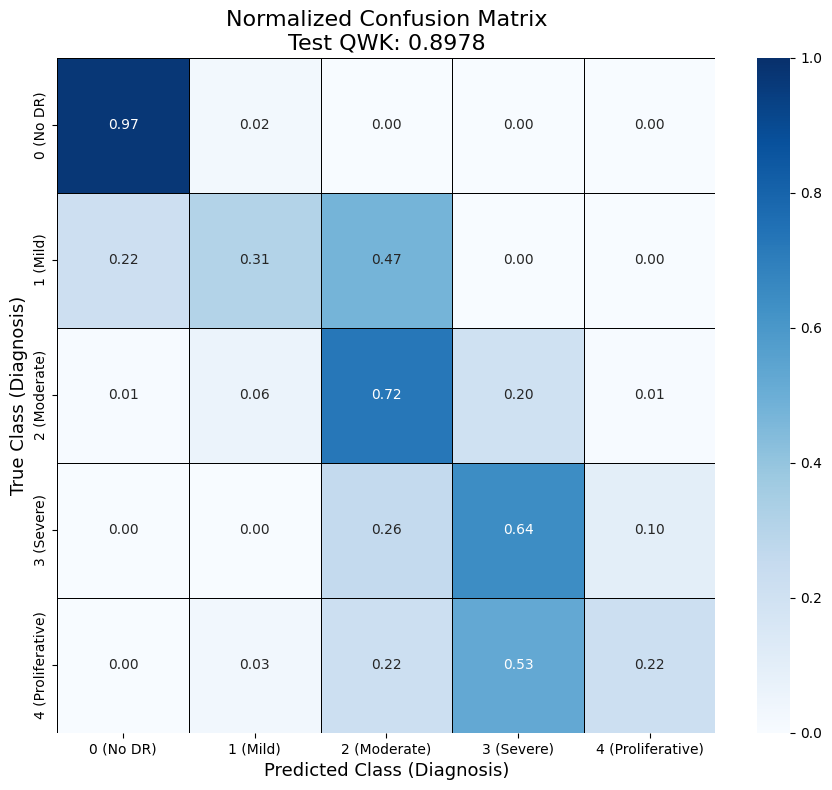

In [ ]:
class_names = ['0 (No DR)', '1 (Mild)', '2 (Moderate)', '3 (Severe)', '4 (Proliferative)']

cm            = confusion_matrix(y_true_test, y_pred_test, labels=range(len(class_names)))
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(9, 8))
sns.heatmap(cm_normalized, annot=True, fmt=".2f", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names,
            linewidths=.5, linecolor='black', vmin=0, vmax=1)

plt.title(f'Normalized Confusion Matrix\nTest QWK: {test_qwk:.4f}', fontsize=16)
plt.ylabel('True Class (Diagnosis)', fontsize=13)
plt.xlabel('Predicted Class (Diagnosis)', fontsize=13)
plt.tight_layout()
plt.show()

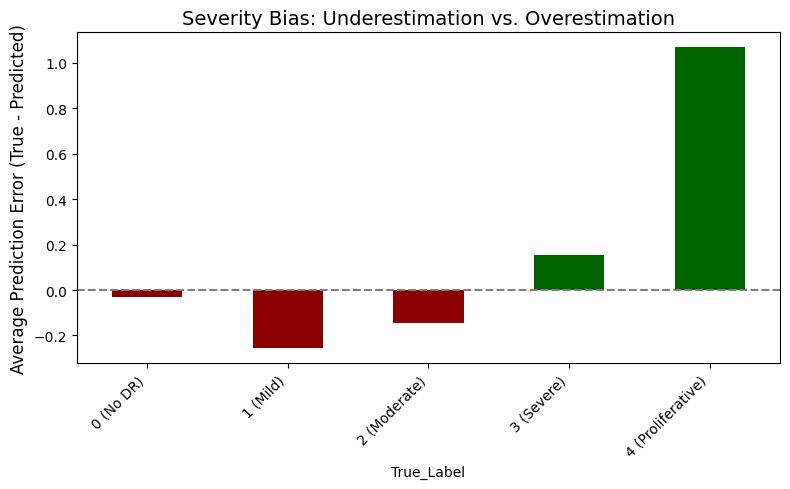

In [ ]:
errors        = y_true_test - y_pred_test
df_results    = pd.DataFrame({'True_Label': y_true_test, 'Error': errors})
error_summary = df_results.groupby('True_Label')['Error'].mean()

plt.figure(figsize=(8, 5))
colors = ['darkred' if x < 0 else 'darkgreen' for x in error_summary]
error_summary.plot(kind='bar', color=colors)

plt.axhline(0, color='gray', linestyle='--')
plt.xticks(ticks=range(5), labels=class_names, rotation=45, ha='right')
plt.ylabel('Average Prediction Error (True - Predicted)', fontsize=12)
plt.title('Severity Bias: Underestimation vs. Overestimation', fontsize=14)
plt.tight_layout()
plt.show()

In [ ]:
from google.colab import files

files.download('/content/drive/MyDrive/best_hybrid_vit_ordinal_model.pt')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>